In [15]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from Components.strategy import BaseStrategy,run_and_plot
plt.style.use('ggplot')

In [12]:
##Data procee
def Bar_data_wrangle(DATA_PATH:str):##follow a model
    raw_df = (
    pd.read_csv(DATA_PATH, parse_dates=['date_time'])
    .set_index('date_time')
    .sort_index()
    )
    raw_df['tradingDay'] = raw_df.index.date
    ohlc_cols = ['open', 'high', 'low', 'close', 'volume', 'tradingDay']
    ohlc_df = raw_df[ohlc_cols].copy()
    price_df = raw_df[['open', 'high', 'low', 'close', 'volume']].copy()

    return raw_df,ohlc_df,price_df

In [13]:
class DualThrustStrategy(BaseStrategy):
    def __init__(self, data: pd.DataFrame, n: int = 20, k1: float = 0.5, k2: float = 0.5):
        super().__init__(data, f'DualThrust_{n}_{k1}_{k2}')
        self.n = n
        self.k1 = k1#超买参数
        self.k2 = k2#超卖参数

    def build_signals(self, df: pd.DataFrame) -> pd.DataFrame:
        # 计算前n日的HH, LL, HC, LC
        hh = df['high'].rolling(self.n).max().shift(1)
        ll = df['low'].rolling(self.n).min().shift(1)
        hc = df['close'].rolling(self.n).max().shift(1)
        lc = df['close'].rolling(self.n).min().shift(1)

        # 计算Range
        range1 = hh - lc
        range2 = hc - ll
        range_val = np.maximum(range1, range2)

        # 计算上下轨
        open_price = df['open']
        upper_bound = open_price + self.k1 * range_val
        lower_bound = open_price - self.k2 * range_val


        short_entry = (df['high'] > upper_bound).fillna(False)
        long_entry = (df['low'] < lower_bound).fillna(False)

        #machine state(pos)
        pos = np.zeros(len(df), dtype=float)
        current_pos = 0

        for i in range(len(df)):
            if long_entry.iloc[i] and current_pos <= 0:
                current_pos = 1
            elif short_entry.iloc[i] and current_pos >= 0:
                current_pos = -1
            pos[i] = current_pos

        #generate entry-signal
        position = pd.Series(pos, index=df.index, name='position')
        return pd.DataFrame({'position': position})

==== Backtest Summary ====
Initial Cash      : 10,000.00
Final Equity      : 32,818.90
Total Return      : 228.19%
Max Drawdown      : -29.33%
Annualized Return : 216.09%
Annualized Vol    : 71.24%
Sharpe (≈)        : 3.03
Trades (fills)    : 13675
Closed Trades     : 6831
Win Rate          : 66.93%
Payoff Ratio      : 0.55
Realized PnL      : 22,800.00


,DualThrust_20_0.5_0.5
total_return,2.281890
annual_return,2.160914
annual_vol,0.712360
sharpe,3.033458
max_drawdown,-0.293288
win_rate,0.493060
trades,6838.000000


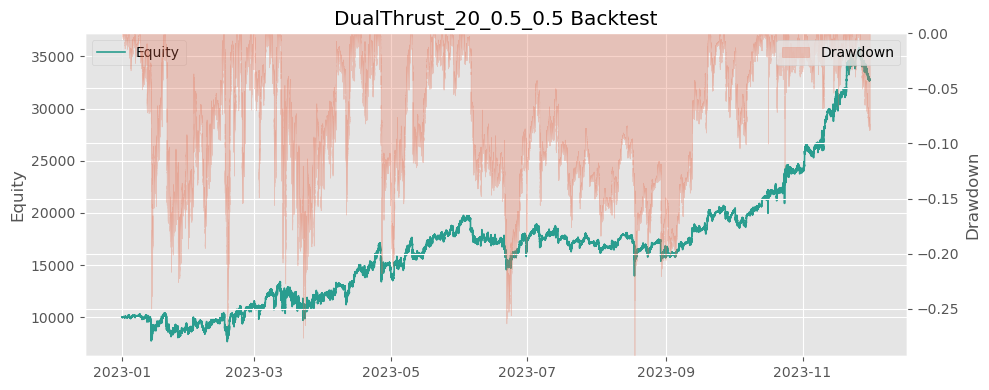

In [16]:
DATA_PATH = Path('E:/Cornell 26 Spring/HFT-trading/ORIE_5270/data/BTCUSDT_futures_1m_2023-01-01_2023-12-01.csv')
raw_df,ohlc_df,price_df=Bar_data_wrangle(DATA_PATH)
dual_thrust_run = run_and_plot(DualThrustStrategy(price_df, n=20, k1=0.5, k2=0.5),ohlc_df)

In [9]:



class ATRStrategy(BaseStrategy):
    def __init__(self, data: pd.DataFrame, atr_n: int = 14, ma_n: int = 20, atr_k: float = 2.0):
        super().__init__(data, f'ATR_{atr_n}_{ma_n}_{atr_k}')
        self.atr_n = atr_n
        self.ma_n = ma_n
        self.atr_k = atr_k

    def build_signals(self, df: pd.DataFrame) -> pd.DataFrame:
        # 计算ATR
        high_low = df['high'] - df['low']
        high_close = np.abs(df['high'] - df['close'].shift(1))
        low_close = np.abs(df['low'] - df['close'].shift(1))
        tr = np.maximum(high_low, np.maximum(high_close, low_close))
        atr = tr.rolling(self.atr_n).mean()
        
        # 计算移动平均线
        ma = df['close'].rolling(self.ma_n).mean()
        
        # 计算上下轨
        upper_band = ma + self.atr_k * atr
        lower_band = ma - self.atr_k * atr
        

        short_entry = (df['close'] > upper_band.shift(1)).fillna(False)
        long_entry = (df['close'] < lower_band.shift(1)).fillna(False)
        
        pos = np.zeros(len(df), dtype=float)
        current_pos = 0
        
        for i in range(len(df)):
            if long_entry.iloc[i] and current_pos <= 0:
                current_pos = 1
            elif short_entry.iloc[i] and current_pos >= 0:
                current_pos = -1
            pos[i] = current_pos
        
        position = pd.Series(pos, index=df.index, name='position')
        return pd.DataFrame({'position': position})


class RBreakerStrategy(BaseStrategy):
    def __init__(self, data: pd.DataFrame, f1: float = 0.35, f2: float = 0.07, f3: float = 0.25):
        super().__init__(data, f'RBreaker_{f1}_{f2}_{f3}')
        self.f1 = f1
        self.f2 = f2
        self.f3 = f3

    def build_signals(self, df: pd.DataFrame) -> pd.DataFrame:
        # 计算前一日的高低收
        prev_high = df['high'].shift(1)
        prev_low = df['low'].shift(1)
        prev_close = df['close'].shift(1)
        
        # 计算六个价位
        pivot = (prev_high + prev_low + prev_close) / 3
        
        # 突破买入价 = HIGH + f1 * (CLOSE - LOW)
        bbreak = prev_high + self.f1 * (prev_close - prev_low)
        # 观察卖出价 = HIGH + f2 * (CLOSE - LOW)
        ssetup = prev_high + self.f2 * (prev_close - prev_low)
        # 反转卖出价 = (1 + f3) * pivot - f3 * LOW
        senter = (1 + self.f3) * pivot - self.f3 * prev_low
        # 反转买入价 = (1 + f3) * pivot - f3 * HIGH
        benter = (1 + self.f3) * pivot - self.f3 * prev_high
        # 观察买入价 = LOW - f2 * (HIGH - CLOSE)
        bsetup = prev_low - self.f2 * (prev_high - prev_close)
        # 突破卖出价 = LOW - f1 * (HIGH - CLOSE)
        sbreak = prev_low - self.f1 * (prev_high - prev_close)
        
        pos = np.zeros(len(df), dtype=float)
        current_pos = 0
        
        for i in range(len(df)):
            if pd.isna(bbreak.iloc[i]):
                pos[i] = current_pos
                continue
                
            high_i = df['high'].iloc[i]
            low_i = df['low'].iloc[i]
            
            # 突破策略（
            if low_i < sbreak.iloc[i] and current_pos <= 0:
                current_pos = 1
            elif high_i > bbreak.iloc[i] and current_pos >= 0:
                current_pos = -1
            # 反转策略（
            elif low_i < bsetup.iloc[i] and current_pos > 0:
                if high_i > benter.iloc[i]:
                    current_pos = -1
            elif high_i > ssetup.iloc[i] and current_pos < 0:
                if low_i < senter.iloc[i]:
                    current_pos = 1
            
            pos[i] = current_pos
        
        position = pd.Series(pos, index=df.index, name='position')
        return pd.DataFrame({'position': position})


class FourPriceStrategy(BaseStrategy):
    def __init__(self, data: pd.DataFrame, n: int = 20):
        super().__init__(data, f'FourPrice_{n}')
        self.n = n

    def build_signals(self, df: pd.DataFrame) -> pd.DataFrame:
        # 计算前n日的四个价格
        hh = df['high'].rolling(self.n).max().shift(1)  # 最高价
        ll = df['low'].rolling(self.n).min().shift(1)   # 最低价
        hc = df['close'].rolling(self.n).max().shift(1) # 最高收盘价
        lc = df['close'].rolling(self.n).min().shift(1) # 最低收盘价
        
        # 生成信号：跌破最低价做多，突破最高价做空
        long_entry = (df['low'] < ll).fillna(False)
        short_entry = (df['high'] > hh).fillna(False)
        
        # 出场信号：多头涨破最高收盘价，空头跌破最低收盘价
        long_exit = (df['high'] > hc).fillna(False)
        short_exit = (df['low'] < lc).fillna(False)
        
        pos = np.zeros(len(df), dtype=float)
        current_pos = 0
        
        for i in range(len(df)):
            if current_pos > 0:  # 持多头
                if long_exit.iloc[i]:
                    current_pos = 0
                else:
                    current_pos = 1
            elif current_pos < 0:  # 持空头
                if short_exit.iloc[i]:
                    current_pos = 0
                else:
                    current_pos = -1
            else:  # 空仓
                if long_entry.iloc[i]:
                    current_pos = 1
                elif short_entry.iloc[i]:
                    current_pos = -1
            
            pos[i] = current_pos
        
        position = pd.Series(pos, index=df.index, name='position')
        return pd.DataFrame({'position': position})


==== Backtest Summary ====
Initial Cash      : 10,000.00
Final Equity      : 32,818.90
Total Return      : 228.19%
Max Drawdown      : -29.33%
Annualized Return : 216.09%
Annualized Vol    : 71.24%
Sharpe (≈)        : 3.03
Trades (fills)    : 13675
Closed Trades     : 6831
Win Rate          : 66.93%
Payoff Ratio      : 0.55
Realized PnL      : 22,800.00


,DualThrust_20_0.5_0.5
total_return,2.281890
annual_return,2.160914
annual_vol,0.712360
sharpe,3.033458
max_drawdown,-0.293288
win_rate,0.493060
trades,6838.000000


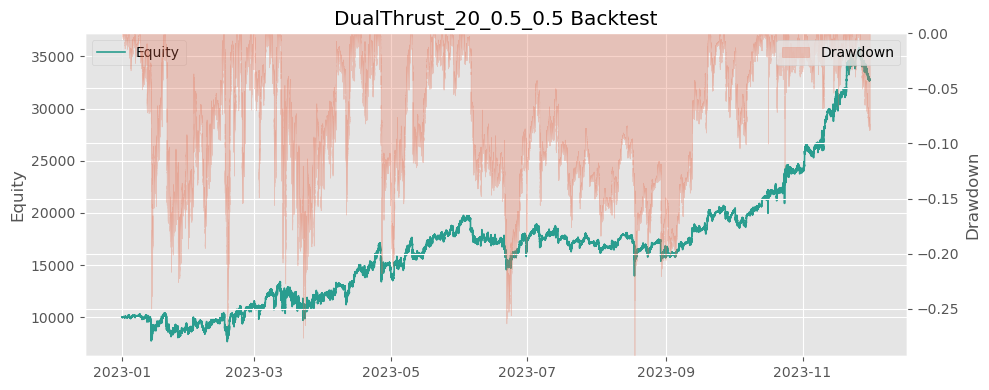

In [10]:
DATA_PATH = Path('../data/BTCUSDT_futures_1m_2023-01-01_2023-12-01.csv')
raw_df,ohlc_df,price_df=Bar_data_wrangle(DATA_PATH)

dual_thrust_run = run_and_plot(DualThrustStrategy(price_df, n=20, k1=0.5, k2=0.5),ohlc_df)

==== Backtest Summary ====
Initial Cash      : 10,000.00
Final Equity      : 23,933.20
Total Return      : 139.33%
Max Drawdown      : -32.16%
Annualized Return : 151.92%
Annualized Vol    : 72.78%
Sharpe (≈)        : 2.09
Trades (fills)    : 27973
Closed Trades     : 13965
Win Rate          : 67.27%
Payoff Ratio      : 0.51
Realized PnL      : 13,943.80


,ATR_14_20_2.0
total_return,1.393320
annual_return,1.519198
annual_vol,0.727831
sharpe,2.087294
max_drawdown,-0.321646
win_rate,0.495025
trades,13987.000000


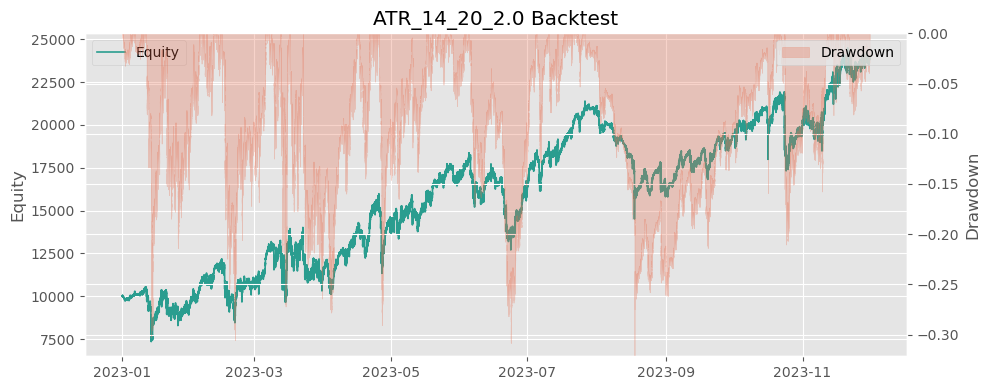

In [12]:
atr_run = run_and_plot(ATRStrategy(price_df, atr_n=14, ma_n=20, atr_k=2.0),ohlc_df)

==== Backtest Summary ====
Initial Cash      : 10,000.00
Final Equity      : 20,219.40
Total Return      : 102.19%
Max Drawdown      : -59.54%
Annualized Return : 123.05%
Annualized Vol    : 73.57%
Sharpe (≈)        : 1.67
Trades (fills)    : 529991
Closed Trades     : 263811
Win Rate          : 52.68%
Payoff Ratio      : 0.90
Realized PnL      : 10,238.50


,RBreaker_0.35_0.07_0.25
total_return,1.021940
annual_return,1.230514
annual_vol,0.735719
sharpe,1.672533
max_drawdown,-0.595350
win_rate,0.485209
trades,264996.000000


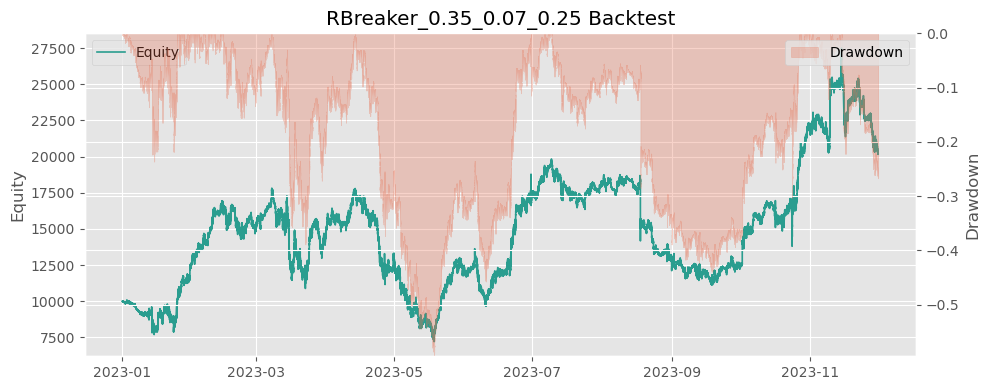

In [23]:
rbreaker_run = run_and_plot(RBreakerStrategy(price_df, f1=0.35, f2=0.07, f3=0.25))

==== Backtest Summary ====
Initial Cash      : 10,000.00
Final Equity      : 32,466.50
Total Return      : 224.67%
Max Drawdown      : -29.77%
Annualized Return : 191.10%
Annualized Vol    : 59.94%
Sharpe (≈)        : 3.19
Trades (fills)    : 31722
Closed Trades     : 15845
Win Rate          : 66.76%
Payoff Ratio      : 0.53
Realized PnL      : 22,466.50


,FourPrice_20
total_return,2.246650
annual_return,1.911035
annual_vol,0.599382
sharpe,3.188342
max_drawdown,-0.297662
win_rate,0.431782
trades,31722.000000


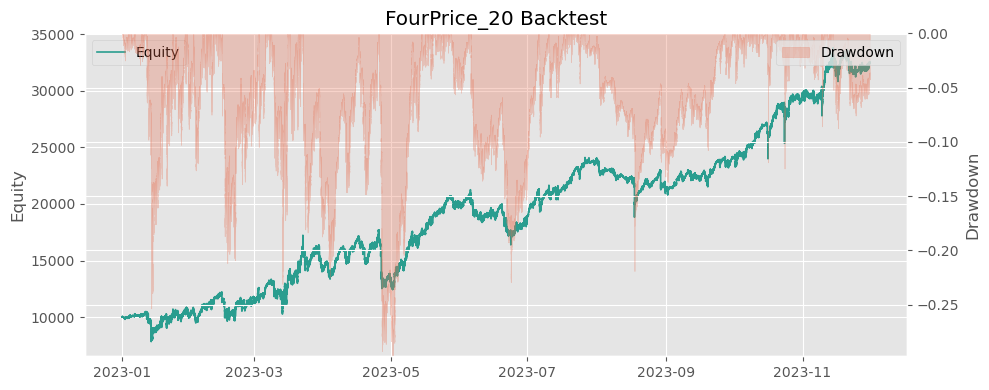

In [24]:
fourprice_run = run_and_plot(FourPriceStrategy(price_df, n=20))

In [8]:
class ChannelBreakoutStrategy(BaseStrategy):
    def __init__(self, data: pd.DataFrame, lookback: int = 100, exit_n: int = 20, atr_n: int = 14, atr_k: float = 0.5):
        super().__init__(data, f'Channel_{lookback}_{exit_n}_{atr_n}_{atr_k}')
        self.lookback = lookback
        self.exit_n = exit_n
        self.atr_n = atr_n
        self.atr_k = atr_k

    def build_signals(self, df: pd.DataFrame) -> pd.DataFrame:
        upper = df['high'].rolling(self.lookback).max().shift(1)
        lower = df['low'].rolling(self.lookback).min().shift(1)
        atr = (df['high'] - df['low']).rolling(self.atr_n).mean()
        long_entry = (df['low'] <= lower - self.atr_k * atr).fillna(False)
        short_entry = (df['high'] >= upper + self.atr_k * atr).fillna(False)

        exit_up = df['high'].rolling(self.exit_n).max().shift(1)
        exit_down = df['low'].rolling(self.exit_n).min().shift(1)
        long_exit = (df['high'] >= exit_up).fillna(False)
        short_exit = (df['low'] <= exit_down).fillna(False)

        pos = np.zeros(len(df), dtype=float)
        have_long = False
        have_short = False
        long_entry_arr = long_entry.to_numpy(dtype=bool)
        short_entry_arr = short_entry.to_numpy(dtype=bool)
        long_exit_arr = long_exit.to_numpy(dtype=bool)
        short_exit_arr = short_exit.to_numpy(dtype=bool)

        for i in range(len(df)):
            if have_long:
                if long_exit_arr[i]:
                    have_long = False
                    pos[i] = 0
                else:
                    pos[i] = 1
            elif have_short:
                if short_exit_arr[i]:
                    have_short = False
                    pos[i] = 0
                else:
                    pos[i] = -1
            else:
                if long_entry_arr[i]:
                    have_long = True
                    pos[i] = 1
                elif short_entry_arr[i]:
                    have_short = True
                    pos[i] = -1

        position = pd.Series(pos, index=df.index, name='position')
        return pd.DataFrame({'position': position})


class DualMovingAverageStrategy(BaseStrategy):
    def __init__(self, data: pd.DataFrame, fast: int = 50, slow: int = 200):
        super().__init__(data, f'DualMA_{fast}_{slow}')
        self.fast = fast
        self.slow = slow

    def build_signals(self, df: pd.DataFrame) -> pd.DataFrame:
        df['ma_fast'] = df['close'].rolling(self.fast).mean()
        df['ma_slow'] = df['close'].rolling(self.slow).mean()
        golden = (df['ma_fast'] > df['ma_slow']) & (df['ma_fast'].shift(1) <= df['ma_slow'].shift(1))
        death = (df['ma_fast'] < df['ma_slow']) & (df['ma_fast'].shift(1) >= df['ma_slow'].shift(1))
        position = np.select([golden, death], [1, -1], default=np.nan)
        return pd.DataFrame({'position': position}, index=df.index)


class AlligatorStrategy(BaseStrategy):
    def __init__(
        self,
        data: pd.DataFrame,
        jaw: int = 13,
        teeth: int = 8,
        lips: int = 5,
        jaw_shift: int = 8,
        teeth_shift: int = 5,
        lips_shift: int = 3,
    ):
        super().__init__(data, 'Alligator')
        self.jaw = jaw
        self.teeth = teeth
        self.lips = lips
        self.jaw_shift = jaw_shift
        self.teeth_shift = teeth_shift
        self.lips_shift = lips_shift

    @staticmethod
    def _smoothed(series: pd.Series, period: int) -> pd.Series:
        return series.ewm(alpha=1 / period, adjust=False).mean()

    def build_signals(self, df: pd.DataFrame) -> pd.DataFrame:
        jaw_line = self._smoothed(df['close'], self.jaw).shift(self.jaw_shift)
        teeth_line = self._smoothed(df['close'], self.teeth).shift(self.teeth_shift)
        lips_line = self._smoothed(df['close'], self.lips).shift(self.lips_shift)
        position = np.select(
            [
                (lips_line > teeth_line) & (teeth_line > jaw_line),
                (lips_line < teeth_line) & (teeth_line < jaw_line),
            ],
            [1, -1],
            default=np.nan,
        )
        return pd.DataFrame({'position': position}, index=df.index)


## 通道突破策略

==== Backtest Summary ====
Initial Cash      : 10,000.00
Final Equity      : 27,443.30
Total Return      : 174.43%
Max Drawdown      : -41.02%
Annualized Return : 145.90%
Annualized Vol    : 52.47%
Sharpe (≈)        : 2.78
Trades (fills)    : 11130
Closed Trades     : 5562
Win Rate          : 71.29%
Payoff Ratio      : 0.45
Realized PnL      : 17,443.30


,Channel_100_20_14_0.5
total_return,1.744330
annual_return,1.459024
annual_vol,0.524734
sharpe,2.780499
max_drawdown,-0.410237
win_rate,0.182520
trades,11130.000000


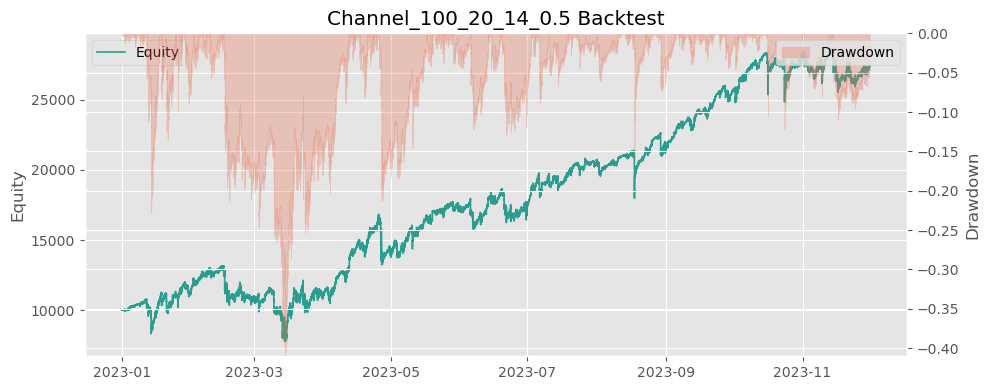

In [9]:

channel_run = run_and_plot(ChannelBreakoutStrategy(price_df, lookback=100))


## 双均线策略

==== Backtest Summary ====
Initial Cash      : 10,000.00
Final Equity      : 21,123.10
Total Return      : 111.23%
Max Drawdown      : -33.49%
Annualized Return : 102.76%
Annualized Vol    : 53.45%
Sharpe (≈)        : 1.92
Trades (fills)    : 6549
Closed Trades     : 3272
Win Rate          : 32.43%
Payoff Ratio      : 2.23
Realized PnL      : 11,179.90


,DualMA_50_200
total_return,1.112310
annual_return,1.027560
annual_vol,0.534520
sharpe,1.922399
max_drawdown,-0.334885
win_rate,0.480314
trades,3275.000000


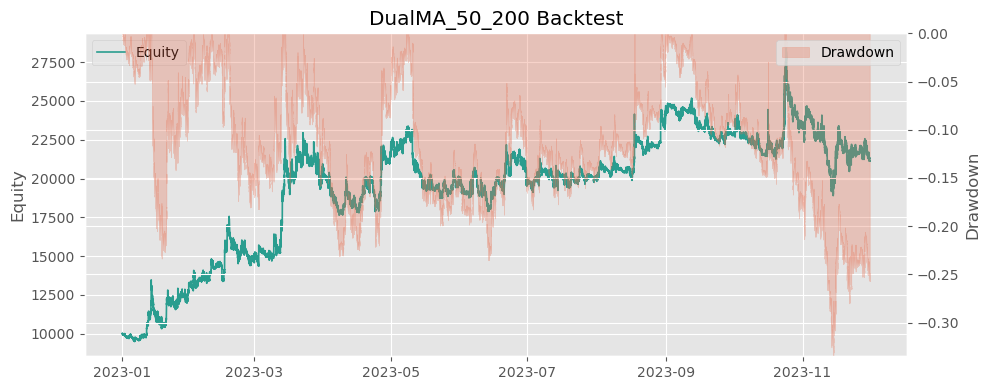

In [10]:

dual_ma_run = run_and_plot(DualMovingAverageStrategy(price_df, fast=50, slow=200))


## 鳄鱼线策略

==== Backtest Summary ====
Initial Cash      : 10,000.00
Final Equity      : 9,045.30
Total Return      : -9.55%
Max Drawdown      : -68.90%
Annualized Return : 44.69%
Annualized Vol    : 94.52%
Sharpe (≈)        : 0.47
Trades (fills)    : 37571
Closed Trades     : 18742
Win Rate          : 37.79%
Payoff Ratio      : 1.64
Realized PnL      : -958.80


,Alligator
total_return,-0.095470
annual_return,0.446884
annual_vol,0.945240
sharpe,0.472773
max_drawdown,-0.688963
win_rate,0.474570
trades,18786.000000


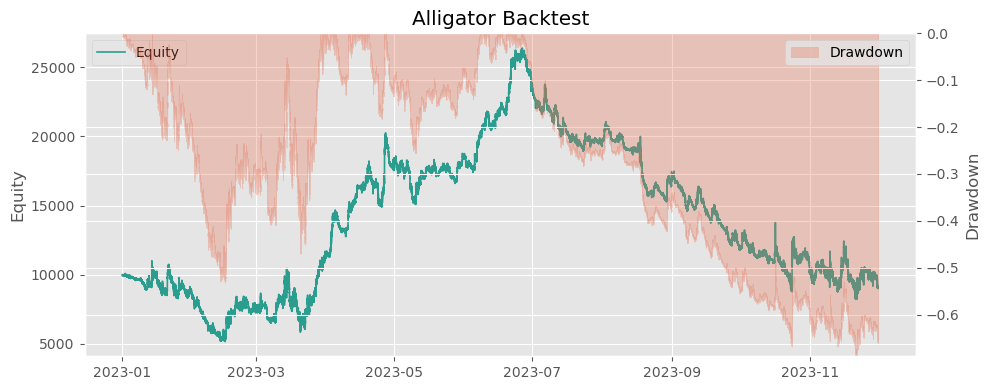

In [11]:

alligator_run = run_and_plot(AlligatorStrategy(price_df))


In [12]:

all_runs = [channel_run, dual_ma_run, alligator_run]
comparison = pd.DataFrame([run.stats for run in all_runs], index=[run.name for run in all_runs])
comparison


,total_return,annual_return,annual_vol,sharpe,max_drawdown,win_rate,trades
Channel_100_20_14_0.5,1.74433,1.459024,0.524734,2.780499,-0.410237,0.182520,11130.0
DualMA_50_200,1.11231,1.027560,0.534520,1.922399,-0.334885,0.480314,3275.0
Alligator,-0.09547,0.446884,0.945240,0.472773,-0.688963,0.474570,18786.0


In [13]:
loss_diag = []
for run in all_runs:
    df = run.daily_df
    avg_trades = df['trade_count'].mean()
    avg_turnover = df['turnover'].mean()
    signal_churn = run.signal_df['position'].diff().abs().sum() / 2
    loss_diag.append(
        {
            'strategy': run.name,
            'final_net_value': df['net_value'].iloc[-1],
            'win_rate': run.stats['win_rate'],
            'avg_daily_trades': avg_trades,
            'avg_daily_turnover': avg_turnover,
            'signal_flips': signal_churn,
        }
    )
loss_df = pd.DataFrame(loss_diag)
loss_df


,strategy,final_net_value,win_rate,avg_daily_trades,avg_daily_turnover,signal_flips
0,Channel_100_20_14_0.5,2.74433,0.182520,0.023141,636.532309,5565.0
1,DualMA_50_200,2.11231,0.480314,0.006809,375.536698,21.0
2,Alligator,0.90453,0.474570,0.039059,2146.935831,285.0
